#Import modules

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [2]:
import pandas as pd
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt

In [3]:
import joblib
from sklearn.multioutput import MultiOutputRegressor
from sklearn.model_selection import GridSearchCV
from sklearn.impute import SimpleImputer
from sklearn.linear_model import Ridge
from sklearn.metrics import r2_score, mean_squared_error
from sklearn.model_selection import cross_val_score, KFold
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

#Set results path

In [4]:
results_path = 'drive/My Drive/Colab Notebooks/Metabolite_prediction_ML/Tissue_res'

#Functions

In [5]:
def get_r2_mse_rmse_plot_pred(data_y_test, model_predictions, model_type):

  r2 = r2_score(data_y_test, model_predictions)
  mse = mean_squared_error(data_y_test, model_predictions)
  rmse = mse**0.5

  print(f"R-squared: {r2}")
  print(f"Mean Squared Error (MSE): {mse}")
  print(f"Root Mean Squared Error (RMSE): {rmse}")


  plt.figure(figsize=(8, 6))
  for i in range(data_y_test.shape[1]):
      plt.scatter(data_y_test.iloc[:, i], model_predictions[:, i], alpha=0.5)

  plt.plot([data_y_test.min().min(), data_y_test.max().max()], [data_y_test.min().min(), data_y_test.max().max()], 'k--', lw=2, label='Ideal')

  plt.xlabel("Actual Values")
  plt.ylabel("Predicted Values")
  plt.title(f"Predicted vs. Actual Values for Metabolites ({model_type})")
  plt.legend(bbox_to_anchor=(1.05, 1), loc='upper right')
  plt.grid(True)
  plt.savefig(f'{results_path}/{model_type}.svg', bbox_inches = 'tight')
  plt.show()

In [6]:
def plot_cv_scores(model_pipeline, model_type, cv_fold):

    # Impute missing values in 'rna' before cross-validation
    imputer_rna = SimpleImputer(strategy='mean')  # Use the same strategy as for metabolites
    rna_imputed = imputer_rna.fit_transform(rna)
    rna_imputed = pd.DataFrame(rna_imputed, columns=rna.columns, index=rna.index)

    imputer_metabolites = SimpleImputer(strategy='mean')
    metabolites_imputed = imputer_metabolites.fit_transform(metabolites)
    metabolites_imputed = pd.DataFrame(metabolites_imputed, columns=metabolites.columns, index=metabolites.index)

    # Use the imputed 'rna' data for cross-validation
    scores = cross_val_score(model_pipeline, rna_imputed, metabolites_imputed, cv=cv_fold, scoring='neg_mean_squared_error', n_jobs=-1)

    print("Cross-validation scores:", scores)
    print("Average score:", scores.mean())

    scores = pd.DataFrame(scores)
    scores = scores.rename(columns={0: 'Cross-validation scores'})
    scores['Cross-validation fold'] = [i + 1 for i in range(len(scores))]

    sns.lineplot(data=scores, x='Cross-validation fold', y='Cross-validation scores')
    plt.ylabel('Negative MSE')
    plt.title('Negative MSE fluctuation with CV-fold')
    plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.savefig(f'{results_path}/MSE vs CV ({model_type}).svg', bbox_inches='tight')
    plt.show()

In [7]:
def get_r2_cross_val(model, model_name):
  cv = KFold(n_splits=10, shuffle=True, random_state=0)

  # Impute missing values in X_train before cross-validation
  imputer = SimpleImputer(strategy='mean')  # or any other suitable strategy
  X_train_imputed = imputer.fit_transform(X_train)

  # Use the imputed data for cross-validation
  scores = cross_val_score(model, X_train_imputed, y_train, cv=cv, scoring='r2', n_jobs=-1)

  print("Cross-validation R-squared scores:", scores)
  print("Average R-squared score:", scores.mean())

  scores_df = pd.DataFrame({'Fold': range(1, len(scores) + 1), 'R-squared': scores})

  # Plot the scores
  plt.figure(figsize=(8, 6))
  sns.lineplot(x='Fold', y='R-squared', data=scores_df, marker='o')
  plt.title(f'Cross-validation R-squared scores for {model_name}')
  plt.xlabel('Fold')
  plt.ylabel('R-squared')
  plt.savefig(f'{results_path}/R2 vs CV ({model_name}).svg', bbox_inches='tight')
  plt.show()

In [8]:
from sklearn.metrics import mean_squared_error

def get_metrics(y_predicted):

  rmse = mean_squared_error(y_test, y_predicted)
  print("RMSE:", rmse)

  from sklearn.metrics import mean_absolute_error
  mae = mean_absolute_error(y_test, y_predicted)
  print("MAE:", mae)

  from sklearn.metrics import median_absolute_error
  medae = median_absolute_error(y_test, y_predicted,)
  print("MedAE:", medae)

  def mean_absolute_percentage_error(y_true, y_pred):
    y_true, y_pred = np.array(y_true), np.array(y_pred)
    return np.mean(np.abs((y_true - y_pred) / y_true)) * 100

  mape = mean_absolute_percentage_error(y_test, y_predicted)
  print('Mean absolute percentage error:', mape)

In [9]:
from scipy.stats import spearmanr

def get_spearman_correlation(model_predictions, model_name):

  correlation, p_value = spearmanr(X_test, model_predictions)

  correlation_df = pd.DataFrame({'Actual': y_test.values.flatten(), 'Predicted': model_predictions.flatten()})

  # Calculate Spearman's correlation
  correlation, p_value = spearmanr(correlation_df['Actual'], correlation_df['Predicted'])

  # Add correlation and p-value to DataFrame
  correlation_df['Correlation'] = correlation
  correlation_df['P-value'] = p_value

  sns.regplot(x='Actual', y='Predicted', data=correlation_df, line_kws={'color': 'red'})
  plt.title(f'Spearman\'s Correlation ({model_name})')
  plt.xlabel('Actual Values')
  plt.ylabel('Predicted Values')

  # Add correlation and p-value as text
  plt.text(0.1, 0.9, f'Correlation: {correlation:.2f}\nP-value: {p_value:.2f}', transform=plt.gca().transAxes)
  plt.savefig(f'{results_path}/Spearmans Corr ({model_name}).svg', bbox_inches = 'tight')
  plt.show()

In [10]:
#Checking for heteroscedasticity
!pip install statsmodels

import statsmodels.api as sm

def get_residuals_vs_pred_plot(model_predictions, model_name):

  residuals = (y_test - model_predictions).values.ravel()

  plt.figure(figsize=(8, 6))
  plt.scatter(model_predictions.ravel(), residuals, alpha=0.6)
  plt.axhline(y=0, color='red', linestyle='--', linewidth=1)
  plt.title(f"Residuals vs. Predicted Values ({model_name})")
  plt.xlabel("Predicted Values")
  plt.ylabel("Residuals")
  plt.savefig(f'{results_path}/Residuals vs Pred Values ({model_name}).svg', bbox_inches = 'tight')
  plt.show()

In [11]:
def plot_r2_per_metabolite(model, model_name, X_test, y_test, model_1, model_2):
    """Plots the R2 score per metabolite for a given model in descending order."""

    # Impute missing values in X_test before prediction
    imputer = SimpleImputer(strategy='mean')
    X_test_imputed = imputer.fit_transform(X_test)

    # Generate predictions using the base models and stack them
    elastic_net_preds_test = model_1.predict(X_test_imputed)
    xgboost_preds_test = model_2.predict(X_test_imputed)
    stacked_features_test = np.hstack([elastic_net_preds_test, xgboost_preds_test])

    y_pred = model.predict(stacked_features_test)

    r2_scores = []
    for i in range(y_test.shape[1]):
        r2 = r2_score(y_test.iloc[:, i], y_pred[:, i])
        r2_scores.append(r2)

    # Create a DataFrame for sorting
    r2_df = pd.DataFrame({'Metabolite': y_test.columns, 'R2 Score': r2_scores})

    # Sort the DataFrame by R2 scores in descending order
    r2_df = r2_df.sort_values(by=['R2 Score'], ascending=False)

    # Plotting
    plt.figure(figsize=(10, 6))
    plt.bar(range(len(r2_df)), r2_df['R2 Score'])
    plt.xticks()
    plt.xlabel("Metabolite")
    plt.ylabel("R2 Score")
    plt.title(f"R2 Score per Metabolite ({model_name}) - Descending Order")
    plt.tight_layout()
    plt.savefig(f'{results_path}/R2 per metabolite ({model_name}).svg', bbox_inches = 'tight')
    plt.show()

In [12]:
def get_r2_per_metabolite(model, model_name, X_test, y_test):
    """Get the R2 score per metabolite for a given model in descending order."""

    # Impute missing values in X_test before prediction
    imputer = SimpleImputer(strategy='mean')
    X_test_imputed = imputer.fit_transform(X_test)

    # Generate predictions using the base models and stack them
    elastic_net_preds_test = model_1.predict(X_test_imputed)
    xgboost_preds_test = model_2.predict(X_test_imputed)
    stacked_features_test = np.hstack([elastic_net_preds_test, xgboost_preds_test])

    y_pred = model.predict(stacked_features_test)

    r2_scores = []
    for i in range(y_test.shape[1]):
        r2 = r2_score(y_test.iloc[:, i], y_pred[:, i])
        r2_scores.append(r2)

    # Create a DataFrame for sorting
    r2_df = pd.DataFrame({'Metabolite': y_test.columns, 'R2 Score': r2_scores})

    # Sort the DataFrame by R2 scores in descending order
    r2_df = r2_df.sort_values(by=['R2 Score'], ascending=False)

    return r2_df

In [13]:
from scipy.stats import spearmanr

def plot_spearman_per_metabolite(model, model_name, X_test, y_test):
    """Plots the Spearman's correlation coefficient per metabolite for a given model."""
    imputer = SimpleImputer(strategy='mean') # or any other suitable strategy
    X_test_imputed = imputer.fit_transform(X_test)

    # Generate predictions using the base models and stack them
    elastic_net_preds_test = model_1.predict(X_test_imputed) # Assuming model_1 is your ElasticNet model
    xgboost_preds_test = model_2.predict(X_test_imputed) # Assuming model_2 is your XGBoost model
    stacked_features_test = np.hstack([elastic_net_preds_test, xgboost_preds_test])

    y_pred = model.predict(stacked_features_test)  # Get model predictions

    spearman_coeffs = []  # Initialize list to store Spearman's coefficients
    for i in range(y_test.shape[1]):  # Iterate through each metabolite (column)
        coeff, _ = spearmanr(y_test.iloc[:, i], y_pred[:, i])  # Calculate Spearman's coefficient
        spearman_coeffs.append(coeff)  # Add the coefficient to the list

    # Create a DataFrame for sorting
    spearman_df = pd.DataFrame({'Metabolite': y_test.columns, 'Spearman Coefficient': spearman_coeffs})

    # Sort the DataFrame by Spearman's coefficients in descending order
    spearman_df = spearman_df.sort_values(by=['Spearman Coefficient'], ascending=False)

    # Plotting
    plt.figure(figsize=(10, 6))  # Adjust figure size as needed
    plt.bar(range(len(spearman_df)), spearman_df['Spearman Coefficient'])  # Create bar plot of coefficients
    plt.xticks()  # Set x-axis labels to metabolite names
    plt.xlabel("Metabolite")
    plt.ylabel("Spearman's Coefficient")
    plt.title(f"Spearman's Correlation Coefficient per Metabolite ({model_name}) - Descending Order")
    plt.tight_layout()  # Adjust layout to prevent labels from overlapping
    plt.savefig(f'{results_path}/Spearman per metabolite ({model_name}).svg', bbox_inches = 'tight')
    plt.show()

In [14]:
def get_spearman_per_metabolite(model, model_name, X_test, y_test):
    """Get the Spearman's correlation coefficient per metabolite for a given model."""
    imputer = SimpleImputer(strategy='mean') # or any other suitable strategy
    X_test_imputed = imputer.fit_transform(X_test)

    # Generate predictions using the base models and stack them
    elastic_net_preds_test = model_1.predict(X_test_imputed) # Assuming model_1 is your ElasticNet model
    xgboost_preds_test = model_2.predict(X_test_imputed) # Assuming model_2 is your XGBoost model
    stacked_features_test = np.hstack([elastic_net_preds_test, xgboost_preds_test])

    y_pred = model.predict(stacked_features_test)  # Get model predictions

    spearman_coeffs = []  # Initialize list to store Spearman's coefficients
    for i in range(y_test.shape[1]):  # Iterate through each metabolite (column)
        coeff, _ = spearmanr(y_test.iloc[:, i], y_pred[:, i])  # Calculate Spearman's coefficient
        spearman_coeffs.append(coeff)  # Add the coefficient to the list

    # Create a DataFrame for sorting
    spearman_df = pd.DataFrame({'Metabolite': y_test.columns, 'Spearman Coefficient': spearman_coeffs})

    # Sort the DataFrame by Spearman's coefficients in descending order
    spearman_df = spearman_df.sort_values(by=['Spearman Coefficient'], ascending=False)

    return spearman_df

In [15]:
def save_model(model, model_name):
    joblib.dump(model, f'{results_path}/{model_name}.pkl')

#Import data

In [16]:
rna = pd.read_csv('drive/My Drive/Colab Notebooks/Metabolite_prediction_ML/transcriptomics_tpm_metabolism_related_genes_ensembl_id.csv', index_col = 0)
rna = rna.T
rna

,ENSG00000198712,ENSG00000198804,ENSG00000198938,ENSG00000198899,ENSG00000198886,ENSG00000212907,ENSG00000198763,ENSG00000198840,ENSG00000156508,ENSG00000198888,...,ENSG00000205923,ENSG00000183747,ENSG00000066813,ENSG00000182601,ENSG00000156885,ENSG00000182156,ENSG00000166948,ENSG00000197838,ENSG00000167751,ENSG00000182415
DUKE-00651,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2312.188455,NaN,...,5.210511,0.120607,0.075973,0.042173,1.535001,0.000000,0.0,0.038375,0.060810,NaN
DUKE-00652,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1854.414094,NaN,...,5.140856,0.000000,0.000000,0.000000,0.437822,0.000000,0.0,0.036485,0.298714,NaN
DUKE-00653,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2521.493046,NaN,...,5.866129,0.000000,0.014961,0.000000,0.906848,0.064986,0.0,0.022671,0.431106,NaN
DUKE-00654,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,3615.962913,NaN,...,13.270873,0.022549,0.018939,0.000000,243.252497,0.000000,0.0,0.000000,0.000000,NaN
DUKE-00657,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,4045.896211,NaN,...,6.234940,0.000000,0.018148,0.120887,0.330000,0.026276,0.0,0.000000,0.145258,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
MSKC-00483,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,3727.663034,NaN,...,15.775171,0.029958,0.025161,0.000000,0.305025,0.000000,0.0,0.038128,60.821936,NaN
MSKC-00484,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,4620.661214,NaN,...,4.930365,0.000000,0.000000,0.016523,0.120283,0.086196,0.0,0.000000,4.971588,NaN
MSKC-00485,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2403.462293,NaN,...,8.791958,0.015149,0.000000,0.127130,0.154241,0.257906,0.0,0.000000,7.760189,NaN
MSKC-00486,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,5986.593041,NaN,...,5.769025,0.012821,0.000000,0.000000,0.000000,0.000000,0.0,0.000000,2.861628,NaN


In [17]:
metabolites = pd.read_csv('drive/My Drive/Colab Notebooks/Metabolite_prediction_ML/metabolomics_log2.csv', index_col = 0)
metabolites = metabolites.T
metabolites

,"1,2-propanediol","1,5-anhydroglucitol (1,5-AG)",1-arachidonoyl-GPC (20:4n6),1-arachidonoyl-GPE (20:4n6),1-arachidonoyl-GPI (20:4),1-eicosatrienoylglycerophosphocholine (20:3),1-margaroylglycerophosphocholine (17:0),1-linoleoylglycerol (18:2),1-linoleoyl-GPC (18:2),1-linoleoylglycerophosphoethanolamine,...,malonate,metronidazole,N-carboxymethylalanine,N1-Methyl-4-pyridone-3-carboxamide,N6-methyladenosine,nicotinate ribonucleoside,norfluoxetine,palmitoleoyl ethanolamide,succinimide,thyroxine
DUKE-00651,21.037723,19.394321,17.671134,14.233610,14.384728,16.818972,15.262543,14.061858,18.733537,13.836203,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
DUKE-00652,23.959087,19.044231,14.631118,16.423374,16.305192,13.493080,13.337998,16.244013,14.342457,14.410637,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
DUKE-00653,20.682481,19.193116,15.608743,14.400485,15.299840,14.887658,14.486196,15.090475,16.891647,14.514168,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
DUKE-00654,19.963768,19.653941,15.383235,15.369813,14.913759,14.578475,13.337998,14.576805,17.531595,16.108259,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
DUKE-00657,19.677653,20.145794,17.854153,14.785590,14.445883,16.213699,13.337998,14.759995,19.931038,15.195652,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
MSKC-00483,NaN,20.623605,20.772511,22.201466,23.203913,NaN,NaN,23.400548,21.974739,NaN,...,20.905649,19.987368,13.949308,18.857947,18.121721,15.876410,21.917796,14.204030,16.028156,13.218192
MSKC-00484,NaN,19.709740,21.012143,21.916148,21.409801,NaN,NaN,22.066585,23.908872,NaN,...,19.997085,19.987368,18.341589,15.813626,18.832340,15.876410,21.917796,14.081109,15.167041,13.218192
MSKC-00485,NaN,19.393769,20.316594,20.322285,20.074359,NaN,NaN,19.395849,21.530004,NaN,...,20.422488,19.987368,17.367652,19.865964,16.375009,18.547371,21.917796,13.940225,16.306077,13.218192
MSKC-00486,NaN,18.795282,19.099814,21.605296,22.077745,NaN,NaN,21.328106,20.474841,NaN,...,20.117567,19.987368,17.310323,19.386511,16.781328,15.876410,21.917796,13.940225,20.522298,13.218192


In [18]:
threshold = 0.2
nan_percentage = metabolites.isnull().mean()
filtered_metabolites = metabolites.loc[:, nan_percentage <= threshold]
metabolites = filtered_metabolites
metabolites

,"1,5-anhydroglucitol (1,5-AG)",1-arachidonoyl-GPC (20:4n6),1-arachidonoyl-GPE (20:4n6),1-arachidonoyl-GPI (20:4),1-linoleoylglycerol (18:2),1-linoleoyl-GPC (18:2),1-oleoylglycerol (1-monoolein),1-oleoyl-GPE (18:1),1-palmitoleoyl-GPC (16:1),1-palmitoylglycerol (1-monopalmitin),...,urea,uridine,valine,valylglycine,xanthine,xanthosine,3-phosphoglycerate,dehydroascorbate,pyruvate,phosphoenolpyruvate (PEP)
DUKE-00651,19.394321,17.671134,14.233610,14.384728,14.061858,18.733537,14.160222,17.035593,18.238785,16.193003,...,19.791208,17.280007,20.914748,13.103914,15.290542,11.141052,NaN,NaN,NaN,NaN
DUKE-00652,19.044231,14.631118,16.423374,16.305192,16.244013,14.342457,14.630229,17.097542,14.162099,16.343955,...,20.714696,17.931028,20.966490,11.180255,14.081160,15.169395,NaN,NaN,NaN,NaN
DUKE-00653,19.193116,15.608743,14.400485,15.299840,15.090475,16.891647,14.793942,16.787389,15.598227,16.307270,...,20.026746,17.416825,20.626487,12.483334,13.719496,10.940461,NaN,NaN,NaN,NaN
DUKE-00654,19.653941,15.383235,15.369813,14.913759,14.576805,17.531595,13.698657,17.498170,15.382139,14.735908,...,19.417532,17.333397,20.786484,12.785167,15.008995,11.457243,NaN,NaN,NaN,NaN
DUKE-00657,20.145794,17.854153,14.785590,14.445883,14.759995,19.931038,14.140832,16.189295,16.830153,13.092027,...,20.029593,18.298603,20.829264,12.072888,12.760453,10.473938,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
MSKC-00483,20.623605,20.772511,22.201466,23.203913,23.400548,21.974739,23.832628,21.126642,15.528993,23.714071,...,23.642103,22.356899,26.906058,13.804900,20.249497,18.873510,21.795535,21.284580,19.835953,20.788527
MSKC-00484,19.709740,21.012143,21.916148,21.409801,22.066585,23.908872,22.744470,24.818447,19.777455,22.367748,...,23.335062,18.983131,28.243038,16.627670,19.755282,19.011004,22.483612,22.112696,17.565157,21.367133
MSKC-00485,19.393769,20.316594,20.322285,20.074359,19.395849,21.530004,21.115255,21.695953,17.689438,22.340078,...,24.068418,21.271504,28.150188,13.804900,21.861710,20.761065,20.709723,22.940596,19.620601,19.702365
MSKC-00486,18.795282,19.099814,21.605296,22.077745,21.328106,20.474841,22.967082,21.579612,16.366178,22.815021,...,24.338312,22.174396,28.327350,15.008651,21.947564,18.447479,20.908825,21.293467,17.466552,20.561626


#Remove outliers

In [19]:
from sklearn.ensemble import IsolationForest
from sklearn.impute import SimpleImputer

def remove_outliers_isolationforest(data, contamination=0.05):
    """Removes outliers using Isolation Forest."""

    # Handle missing values before applying Isolation Forest
    imputer = SimpleImputer(strategy='mean')  # You can use 'median' or another strategy
    data_clean = imputer.fit_transform(data)

    iso = IsolationForest(contamination=contamination)
    yhat = iso.fit_predict(data_clean)
    filtered_data = data[yhat != -1]  # -1 indicates outliers
    return filtered_data

# Apply to your data
filtered_rna = remove_outliers_isolationforest(rna)
filtered_metabolites = remove_outliers_isolationforest(metabolites)

In [20]:
rna = filtered_rna
metabolites = filtered_metabolites

In [21]:
rna

,ENSG00000198712,ENSG00000198804,ENSG00000198938,ENSG00000198899,ENSG00000198886,ENSG00000212907,ENSG00000198763,ENSG00000198840,ENSG00000156508,ENSG00000198888,...,ENSG00000205923,ENSG00000183747,ENSG00000066813,ENSG00000182601,ENSG00000156885,ENSG00000182156,ENSG00000166948,ENSG00000197838,ENSG00000167751,ENSG00000182415
DUKE-00652,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1854.414094,NaN,...,5.140856,0.000000,0.000000,0.000000,0.437822,0.000000,0.0,0.036485,0.298714,NaN
DUKE-00654,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,3615.962913,NaN,...,13.270873,0.022549,0.018939,0.000000,243.252497,0.000000,0.0,0.000000,0.000000,NaN
DUKE-00657,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,4045.896211,NaN,...,6.234940,0.000000,0.018148,0.120887,0.330000,0.026276,0.0,0.000000,0.145258,NaN
DUKE-00658,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,3682.835703,NaN,...,5.155916,0.009194,0.030887,0.000000,5.054815,0.044720,0.0,0.046804,0.160695,NaN
DUKE-00662,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,3734.896468,NaN,...,6.138613,0.015955,0.000000,0.133897,0.649804,0.000000,0.0,0.000000,0.021452,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
MSKC-00479,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,3023.665500,NaN,...,13.129559,0.013697,0.000000,0.000000,0.278912,0.000000,0.0,0.069728,36.628518,NaN
MSKC-00483,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,3727.663034,NaN,...,15.775171,0.029958,0.025161,0.000000,0.305025,0.000000,0.0,0.038128,60.821936,NaN
MSKC-00485,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2403.462293,NaN,...,8.791958,0.015149,0.000000,0.127130,0.154241,0.257906,0.0,0.000000,7.760189,NaN
MSKC-00486,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,5986.593041,NaN,...,5.769025,0.012821,0.000000,0.000000,0.000000,0.000000,0.0,0.000000,2.861628,NaN


#Data shuffling

In [22]:
combined_data = pd.concat([rna, metabolites], axis=1)
shuffled_data = combined_data.sample(frac=1, random_state=0)
shuffled_rna = shuffled_data[rna.columns]
shuffled_metabolites = shuffled_data[metabolites.columns]

rna = shuffled_rna
metabolites = shuffled_metabolites

#Log2 transformation

In [23]:
rna = rna.apply(lambda x: np.log2(x + 1))
rna.head(3)

,ENSG00000198712,ENSG00000198804,ENSG00000198938,ENSG00000198899,ENSG00000198886,ENSG00000212907,ENSG00000198763,ENSG00000198840,ENSG00000156508,ENSG00000198888,...,ENSG00000205923,ENSG00000183747,ENSG00000066813,ENSG00000182601,ENSG00000156885,ENSG00000182156,ENSG00000166948,ENSG00000197838,ENSG00000167751,ENSG00000182415
MSKC-00437,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,11.066737,NaN,...,4.292352,7.340767,8.520052,0.040524,1.714182,0.760004,0.000000,0.000000,0.000000,NaN
MSKC-00601,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,10.490665,NaN,...,3.411428,0.244625,0.355422,0.000000,2.463484,0.124175,0.100624,0.129708,0.000000,0.0
C3L-01157,12.23004,13.526045,13.372191,11.158425,11.424997,10.90795,9.499085,10.520151,9.690684,10.326007,...,NaN,0.006447,0.005808,0.067184,0.948120,0.379928,0.013475,0.029977,0.083721,NaN


#Splitting data

In [24]:
metabolites = metabolites.dropna(axis=1, how='all')
metabolites

,"1,5-anhydroglucitol (1,5-AG)",1-arachidonoyl-GPC (20:4n6),1-arachidonoyl-GPE (20:4n6),1-arachidonoyl-GPI (20:4),1-linoleoylglycerol (18:2),1-linoleoyl-GPC (18:2),1-oleoylglycerol (1-monoolein),1-oleoyl-GPE (18:1),1-palmitoleoyl-GPC (16:1),1-palmitoylglycerol (1-monopalmitin),...,urea,uridine,valine,valylglycine,xanthine,xanthosine,3-phosphoglycerate,dehydroascorbate,pyruvate,phosphoenolpyruvate (PEP)
MSKC-00437,22.646931,19.320289,22.816654,20.912272,23.001326,19.138145,24.921707,20.621435,16.677676,24.553986,...,24.281160,26.121444,29.260272,16.955614,25.502814,19.354513,22.212231,23.844384,18.467045,20.587038
MSKC-00601,22.459676,21.247372,24.057821,22.371074,19.041623,21.606250,19.081462,24.608558,16.597834,23.524125,...,24.029718,22.104775,28.494202,17.310068,22.142132,15.688931,17.359537,15.784009,22.777596,16.698456
C3L-01157,NaN,NaN,19.862000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,17.518000,NaN,24.751000,NaN,NaN,NaN,21.201000,21.574000,17.734000,17.880000
PT-UTHO,NaN,NaN,19.748000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,17.518000,NaN,24.773000,NaN,NaN,NaN,21.132000,21.403000,19.695000,18.644000
CORN-01917,20.998193,16.383929,15.848521,16.142638,16.884597,16.935933,16.452565,17.499835,16.666834,17.377077,...,23.165640,17.370863,23.811908,11.709372,16.173690,15.113739,18.804981,16.929170,14.704887,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
MSKC-00575,21.566847,19.708668,23.931102,21.510611,21.249875,21.024284,22.662528,21.422937,17.294121,23.737990,...,23.088462,24.316288,27.709668,17.310068,24.895626,18.555949,20.746630,20.006674,23.474034,20.057154
MSKC-00401,21.616601,18.512438,23.028355,19.879137,18.660445,21.382817,18.433717,21.884295,18.396894,22.175226,...,25.032915,25.889804,29.394551,16.955614,25.631695,19.401777,24.751880,15.840222,18.946887,23.695717
MSKC-00304,20.754431,17.532092,22.098973,19.968013,19.949980,21.656040,22.702500,24.888175,19.970362,23.759248,...,25.416400,26.620277,29.321918,16.955614,26.217393,20.400648,22.794129,19.517654,15.471989,21.795333
CORN-01909,21.755531,17.240752,15.669045,17.072991,16.552940,17.895445,16.947653,16.625371,16.691284,17.877267,...,23.590241,17.644163,23.957294,12.010399,16.413830,16.737622,19.420232,14.248541,14.704887,NaN


In [25]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(rna, metabolites, test_size=0.2, random_state=0)

In [26]:
from sklearn.impute import SimpleImputer

In [27]:
imputer_train = SimpleImputer(strategy='mean')
y_train_imputed = imputer_train.fit_transform(y_train)

In [28]:
imputer_test = SimpleImputer(strategy='mean')
y_test_imputed = imputer_test.fit_transform(y_test)

In [29]:
y_train = pd.DataFrame(y_train_imputed, columns=y_train.columns, index=y_train.index)
y_test = pd.DataFrame(y_test_imputed, columns=y_test.columns, index=y_test.index)

In [30]:
if y_train.isnull().any().any():
    print("DataFrame contains NaN values")
else:
    print("DataFrame does not contain NaN values")

DataFrame does not contain NaN values


In [31]:
if y_test.isnull().any().any():
    print("DataFrame contains NaN values")
else:
    print("DataFrame does not contain NaN values")

DataFrame does not contain NaN values


In [32]:
y_train_features = y_train.columns
y_train_features

Index(['1,5-anhydroglucitol (1,5-AG)', '1-arachidonoyl-GPC (20:4n6)',
       '1-arachidonoyl-GPE (20:4n6)', '1-arachidonoyl-GPI (20:4)',
       '1-linoleoylglycerol (18:2)', '1-linoleoyl-GPC (18:2)',
       '1-oleoylglycerol (1-monoolein)', '1-oleoyl-GPE (18:1)',
       '1-palmitoleoyl-GPC (16:1)', '1-palmitoylglycerol (1-monopalmitin)',
       ...
       'urea', 'uridine', 'valine', 'valylglycine', 'xanthine', 'xanthosine',
       '3-phosphoglycerate', 'dehydroascorbate', 'pyruvate',
       'phosphoenolpyruvate (PEP)'],
      dtype='object', length=218)

#Ensemble training

In [33]:
'''
Ensemble architecture:

base models: elastic net + random forest regressor
final estimator: ridge regression

'''

'\nEnsemble architecture:\n\nbase models: elastic net + random forest regressor\nfinal estimator: ridge regression\n\n'

In [34]:
model_1 = joblib.load('drive/My Drive/Colab Notebooks/Metabolite_prediction_ML/Tissue_res/ElasticNet.pkl')

In [35]:
model_2 = joblib.load('drive/My Drive/Colab Notebooks/Metabolite_prediction_ML/Tissue_res/Random Forest Regressor.pkl')

In [36]:
model_1_preds = model_1.predict(X_train)
model_2_preds = model_2.predict(X_train)

stacked_features_train = np.hstack([model_1_preds, model_2_preds])

In [37]:
param_grid = {'alpha': [0.1, 1, 2, 4, 6, 8, 10, 50, 100, 110, 125, 130, 140, 150, 175, 200]}

ridge = Ridge(random_state = 0)
grid_search = GridSearchCV(ridge, param_grid, cv=5, scoring='neg_mean_squared_error')
grid_search.fit(stacked_features_train, y_train)

final_estimator = grid_search.best_estimator_
print("Best hyperparameters:", grid_search.best_params_)
print("Best score:", grid_search.best_score_)

model_1_preds_test = model_1.predict(X_test)
model_2_preds_test = model_2.predict(X_test)

stacked_features_test = np.hstack([model_1_preds_test, model_2_preds_test])
y_pred = final_estimator.predict(stacked_features_test)

Best hyperparameters: {'alpha': 110}
Best score: -1.081826939232138


In [38]:
save_model(model = final_estimator, model_name = 'Ensemble')

#Model assessment

R-squared: 0.7841512364672281
Mean Squared Error (MSE): 1.3719244030599758
Root Mean Squared Error (RMSE): 1.1712917668369294


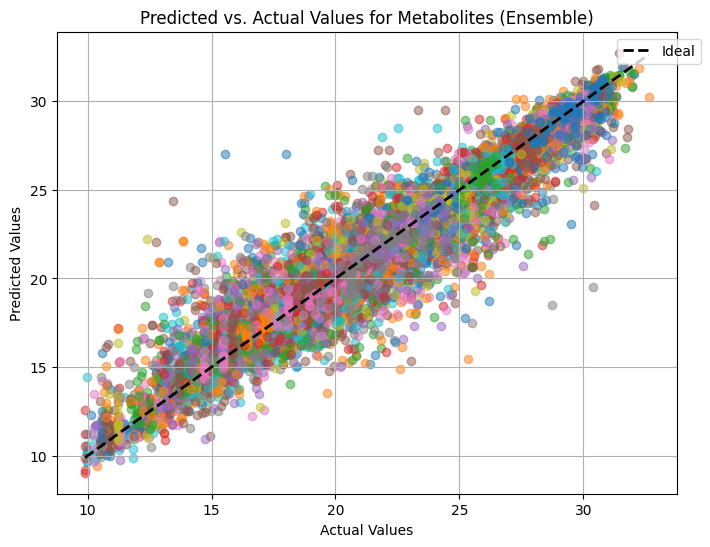

In [39]:
get_r2_mse_rmse_plot_pred(data_y_test = y_test, model_predictions = y_pred, model_type = 'Ensemble')

Cross-validation scores: [-2.53561012 -2.50992844 -2.14159436 -2.51204423 -2.45394059 -2.72633522
 -1.61689273 -2.29351921 -1.94617165 -1.98385586]
Average score: -2.2719892409222266


/tmp/ipython-input-1496117402.py:25: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')


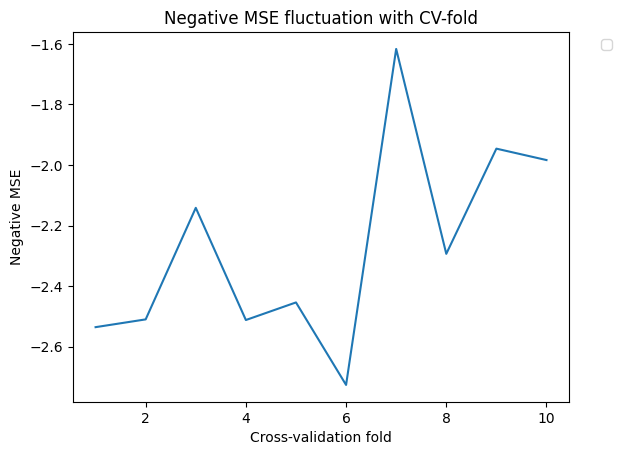

In [40]:
plot_cv_scores(model_pipeline = final_estimator, model_type = 'Ensemble', cv_fold = 10)

Cross-validation R-squared scores: [0.63336351 0.58335736 0.65406206 0.58795438 0.57505836 0.65047287
 0.48012715 0.62345291 0.6443238  0.55597119]
Average R-squared score: 0.5988143586860083


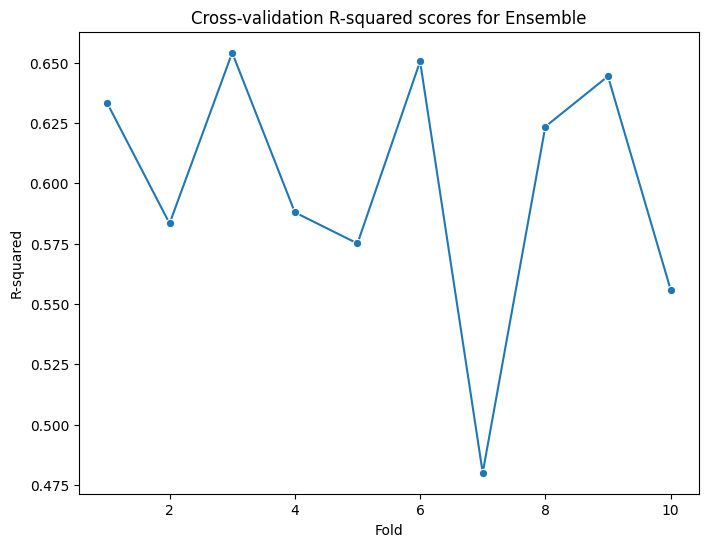

In [41]:
get_r2_cross_val(model = final_estimator, model_name = 'Ensemble')

In [42]:
get_metrics(y_predicted = y_pred)

RMSE: 1.3719244030599758
MAE: 0.7524739116551842
MedAE: 0.4841251966153246
Mean absolute percentage error: 3.7807997336536836


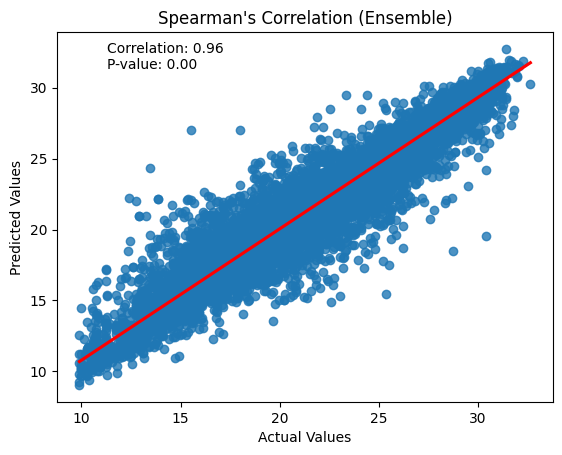

In [43]:
get_spearman_correlation(model_predictions = y_pred, model_name = 'Ensemble')

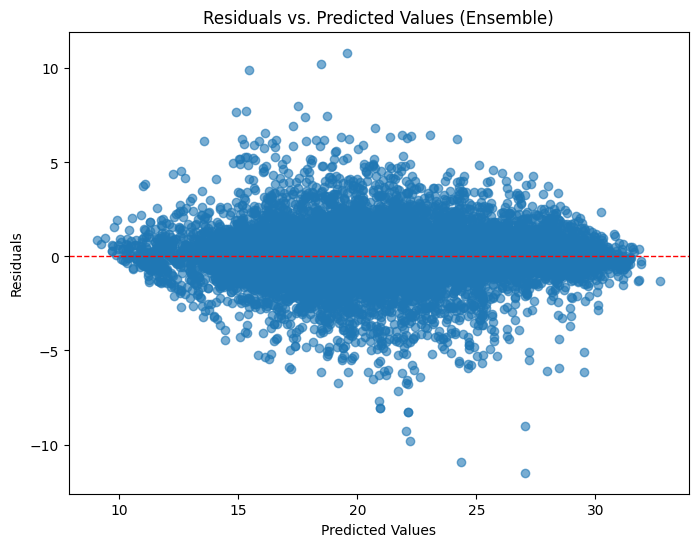

In [44]:
get_residuals_vs_pred_plot(model_predictions = y_pred, model_name = 'Ensemble')

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but SimpleImputer was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but SimpleImputer was fitted with feature names
  warnings.warn(


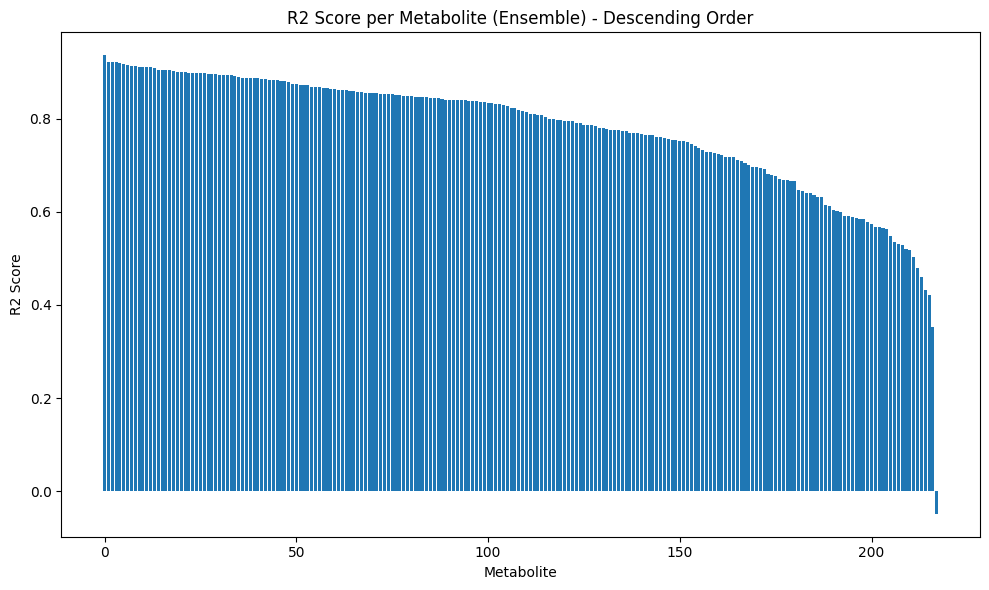

In [45]:
plot_r2_per_metabolite(final_estimator, "Ensemble", X_test, y_test, model_1, model_2)

In [46]:
r2_ensemble = get_r2_per_metabolite(final_estimator, 'Ensemble', X_test, y_test)
r2_ensemble

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but SimpleImputer was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but SimpleImputer was fitted with feature names
  warnings.warn(


,Metabolite,R2 Score
195,stearoyl sphingomyelin (d18:1/18:0),0.936145
149,myristoleate (14:1n5),0.922622
108,glycerate,0.922546
71,creatine,0.922196
183,pyroglutamine,0.918921
...,...,...
134,leucylglycine,0.459108
26,2-palmitoyl-GPC (16:0),0.432173
91,fructose,0.421778
0,"1,5-anhydroglucitol (1,5-AG)",0.351805


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but SimpleImputer was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but SimpleImputer was fitted with feature names
  warnings.warn(


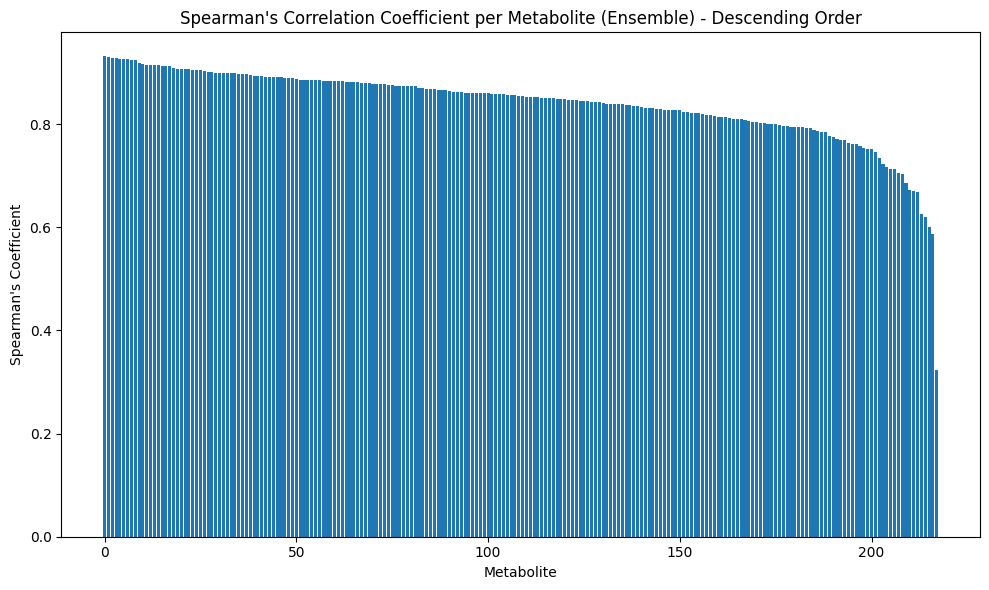

In [47]:
plot_spearman_per_metabolite(final_estimator, 'Ensemble', X_test, y_test)

In [48]:
spearman_ensemble = get_spearman_per_metabolite(final_estimator, 'Ensemble', X_test, y_test)
spearman_ensemble

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but SimpleImputer was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but SimpleImputer was fitted with feature names
  warnings.warn(


,Metabolite,Spearman Coefficient
49,alanine,0.931626
183,pyroglutamine,0.929452
28,3-aminoisobutyrate,0.929359
43,acetylcarnitine,0.928914
204,tryptophan betaine,0.927245
...,...,...
0,"1,5-anhydroglucitol (1,5-AG)",0.626577
134,leucylglycine,0.619990
126,inositol 1-phosphate (I1P),0.600974
103,"glutamate, gamma-methyl ester",0.587106


In [49]:
r2_ensemble.to_csv(f'{results_path}/r2_ensemble.csv', index = False)
spearman_ensemble.to_csv(f'{results_path}/spearman_ensemble.csv', index = False)